# 0.2.2 수치적분

In [2]:
import numpy as np

f = lambda x: x * np.exp(x)
exact = 1.0

N = 11
x = np.linspace(0, 1, N)
h = x[1] - x[0]
y = f(x)

rect = np.sum(y[:-1]) * h
print(f"직사각형 : {rect:.10f}   오차 = {abs(rect - exact):.3f}")

직사각형 : 0.8677819518   오차 = 0.132


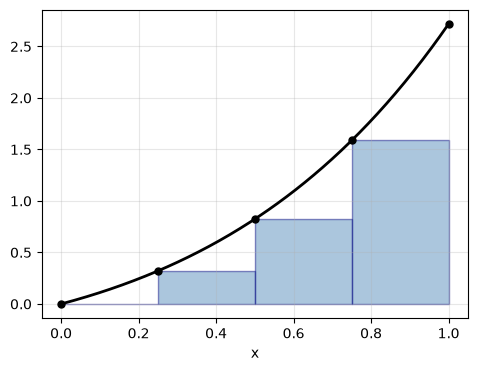

In [6]:
import matplotlib.pyplot as plt

xf = np.linspace(0, 1, 300)
xn = np.linspace(0, 1, 5)

fig, ax = plt.subplots(figsize=(5.5, 4))
for i in range(len(xn) - 1):
    ax.add_patch(
        plt.Rectangle(
            (xn[i], 0),
            xn[i + 1] - xn[i],
            f(xn[i]),
            fc="steelblue",
            ec="navy",
            alpha=0.45,
        )
    )
ax.plot(xf, f(xf), color="black", lw=2, zorder=5)
ax.plot(xn, f(xn), "o", color="black", ms=5, zorder=6)
ax.set_xlabel("x")
ax.grid(alpha=0.3)
plt.show()

In [9]:
trap = np.trapezoid(y, x)
print(f"사다리꼴 : {trap:.10f}   오차 = {abs(trap - exact):.6f}")

사다리꼴 : 1.0036960433   오차 = 0.003696


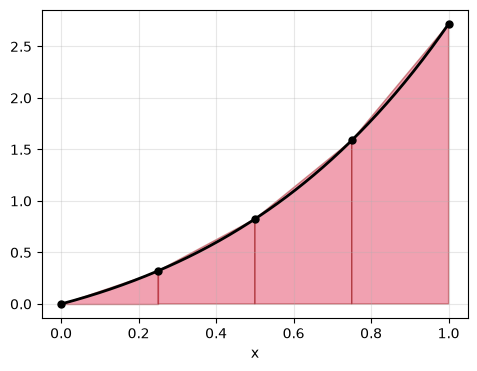

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4))
for i in range(len(xn) - 1):
    ax.fill(
        [xn[i], xn[i + 1], xn[i + 1], xn[i]],
        [0, 0, f(xn[i + 1]), f(xn[i])],
        fc="crimson",
        ec="darkred",
        alpha=0.4,
    )
ax.plot(xf, f(xf), color="black", lw=2, zorder=5)
ax.plot(xn, f(xn), "o", color="black", ms=5, zorder=6)
ax.set_xlabel("x")
ax.grid(alpha=0.3)
plt.show()

In [11]:
from scipy.integrate import simpson

simp = simpson(y, x=x)
print(f"심프슨   : {simp:.10f}   오차 = {abs(simp - exact):.3e}")

심프슨   : 1.0000043665   오차 = 4.366e-06


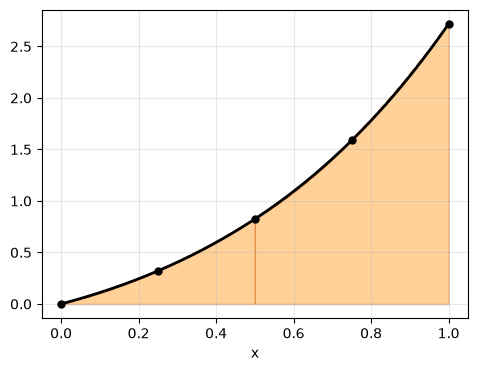

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4))
for i in range(0, len(xn) - 1, 2):
    xs = np.array([xn[i], xn[i + 1], xn[i + 2]])
    c = np.polyfit(xs, f(xs), 2)
    xx = np.linspace(xs[0], xs[-1], 80)
    ax.fill_between(
        xx, 0, np.polyval(c, xx), fc="darkorange", ec="chocolate", alpha=0.4
    )
    ax.plot(xx, np.polyval(c, xx), color="chocolate", lw=1.6, ls="--", zorder=4)
ax.plot(xf, f(xf), color="black", lw=2, zorder=5)
ax.plot(xn, f(xn), "o", color="black", ms=5, zorder=6)
ax.set_xlabel("x")
ax.grid(alpha=0.3)
plt.show()

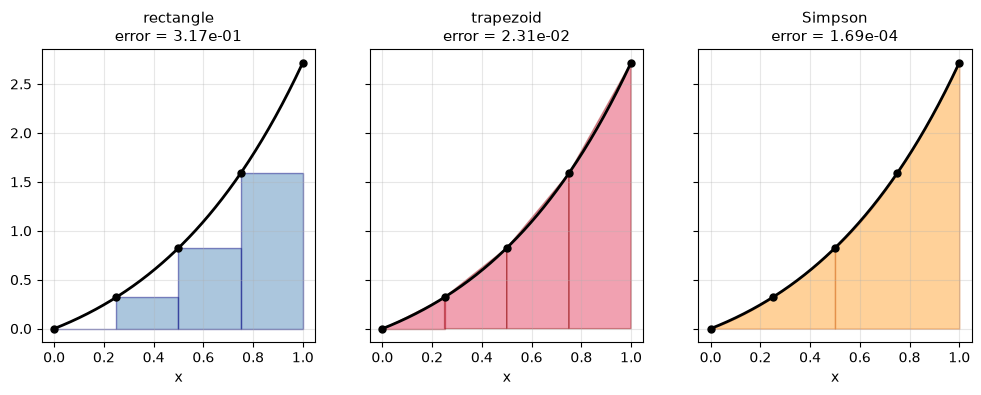

In [13]:
y = f(xn)
h = xn[1] - xn[0]
errs = [
    abs(np.sum(y[:-1]) * h - exact),
    abs(np.trapezoid(y, xn) - exact),
    abs(simpson(y, x=xn) - exact),
]
titles = ["rectangle", "trapezoid", "Simpson"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)

for k, (ax, title) in enumerate(zip(axes, titles)):
    if k == 0:
        for i in range(len(xn) - 1):
            ax.add_patch(
                plt.Rectangle(
                    (xn[i], 0),
                    xn[i + 1] - xn[i],
                    f(xn[i]),
                    fc="steelblue",
                    ec="navy",
                    alpha=0.45,
                )
            )
    elif k == 1:
        for i in range(len(xn) - 1):
            ax.fill(
                [xn[i], xn[i + 1], xn[i + 1], xn[i]],
                [0, 0, f(xn[i + 1]), f(xn[i])],
                fc="crimson",
                ec="darkred",
                alpha=0.4,
            )
    else:
        for i in range(0, len(xn) - 1, 2):
            xs = np.array([xn[i], xn[i + 1], xn[i + 2]])
            c = np.polyfit(xs, f(xs), 2)
            xx = np.linspace(xs[0], xs[-1], 80)
            ax.fill_between(
                xx, 0, np.polyval(c, xx), fc="darkorange", ec="chocolate", alpha=0.4
            )
    ax.plot(xf, f(xf), color="black", lw=2, zorder=5)
    ax.plot(xn, f(xn), "o", color="black", ms=5, zorder=6)
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
    ax.set_title(f"{title}\nerror = {errs[k]:.2e}", fontsize=11)

plt.show()

In [14]:
for N in [11, 101, 1001, 10001]:
    x = np.linspace(0, 1, N)
    h = x[1] - x[0]
    y = f(x)
    r = abs(np.sum(y[:-1]) * h - exact)
    t = abs(np.trapezoid(y, x) - exact)
    s = abs(simpson(y, x=x) - exact)
    print(f"N ={N:6d}   직사각형 {r:.3e}   사다리꼴 {t:.3e}   심프슨 {s:.3e}")

N =    11   직사각형 1.322e-01   사다리꼴 3.696e-03   심프슨 4.366e-06
N =   101   직사각형 1.355e-02   사다리꼴 3.697e-05   심프슨 4.374e-10
N =  1001   직사각형 1.359e-03   사다리꼴 3.697e-07   심프슨 4.374e-14
N = 10001   직사각형 1.359e-04   사다리꼴 3.697e-09   심프슨 0.000e+00


In [15]:
for N in [10**3, 10**4, 10**5, 10**6, 10**7]:
    x = np.linspace(0, 1, N)
    err = abs(np.trapezoid(f(x), x) - exact)
    print(f"N = {N:9d}   오차 = {err:.3e}")

N =      1000   오차 = 3.705e-07
N =     10000   오차 = 3.698e-09
N =    100000   오차 = 3.697e-11
N =   1000000   오차 = 3.697e-13
N =  10000000   오차 = 3.553e-15


In [17]:
L = 1.0
x = np.linspace(0, L, 2001)
psi = np.sin(np.pi * x / L)

norm2 = np.trapezoid(psi**2, x)
A = 1 / np.sqrt(norm2)

print(f"적분값       = {norm2}")
print(f"규격화 상수 A = {A}")
print(f"sqrt(2/L)   = {np.sqrt(2/L)}")

적분값       = 0.5
규격화 상수 A = 1.414213562373095
sqrt(2/L)   = 1.4142135623730951
